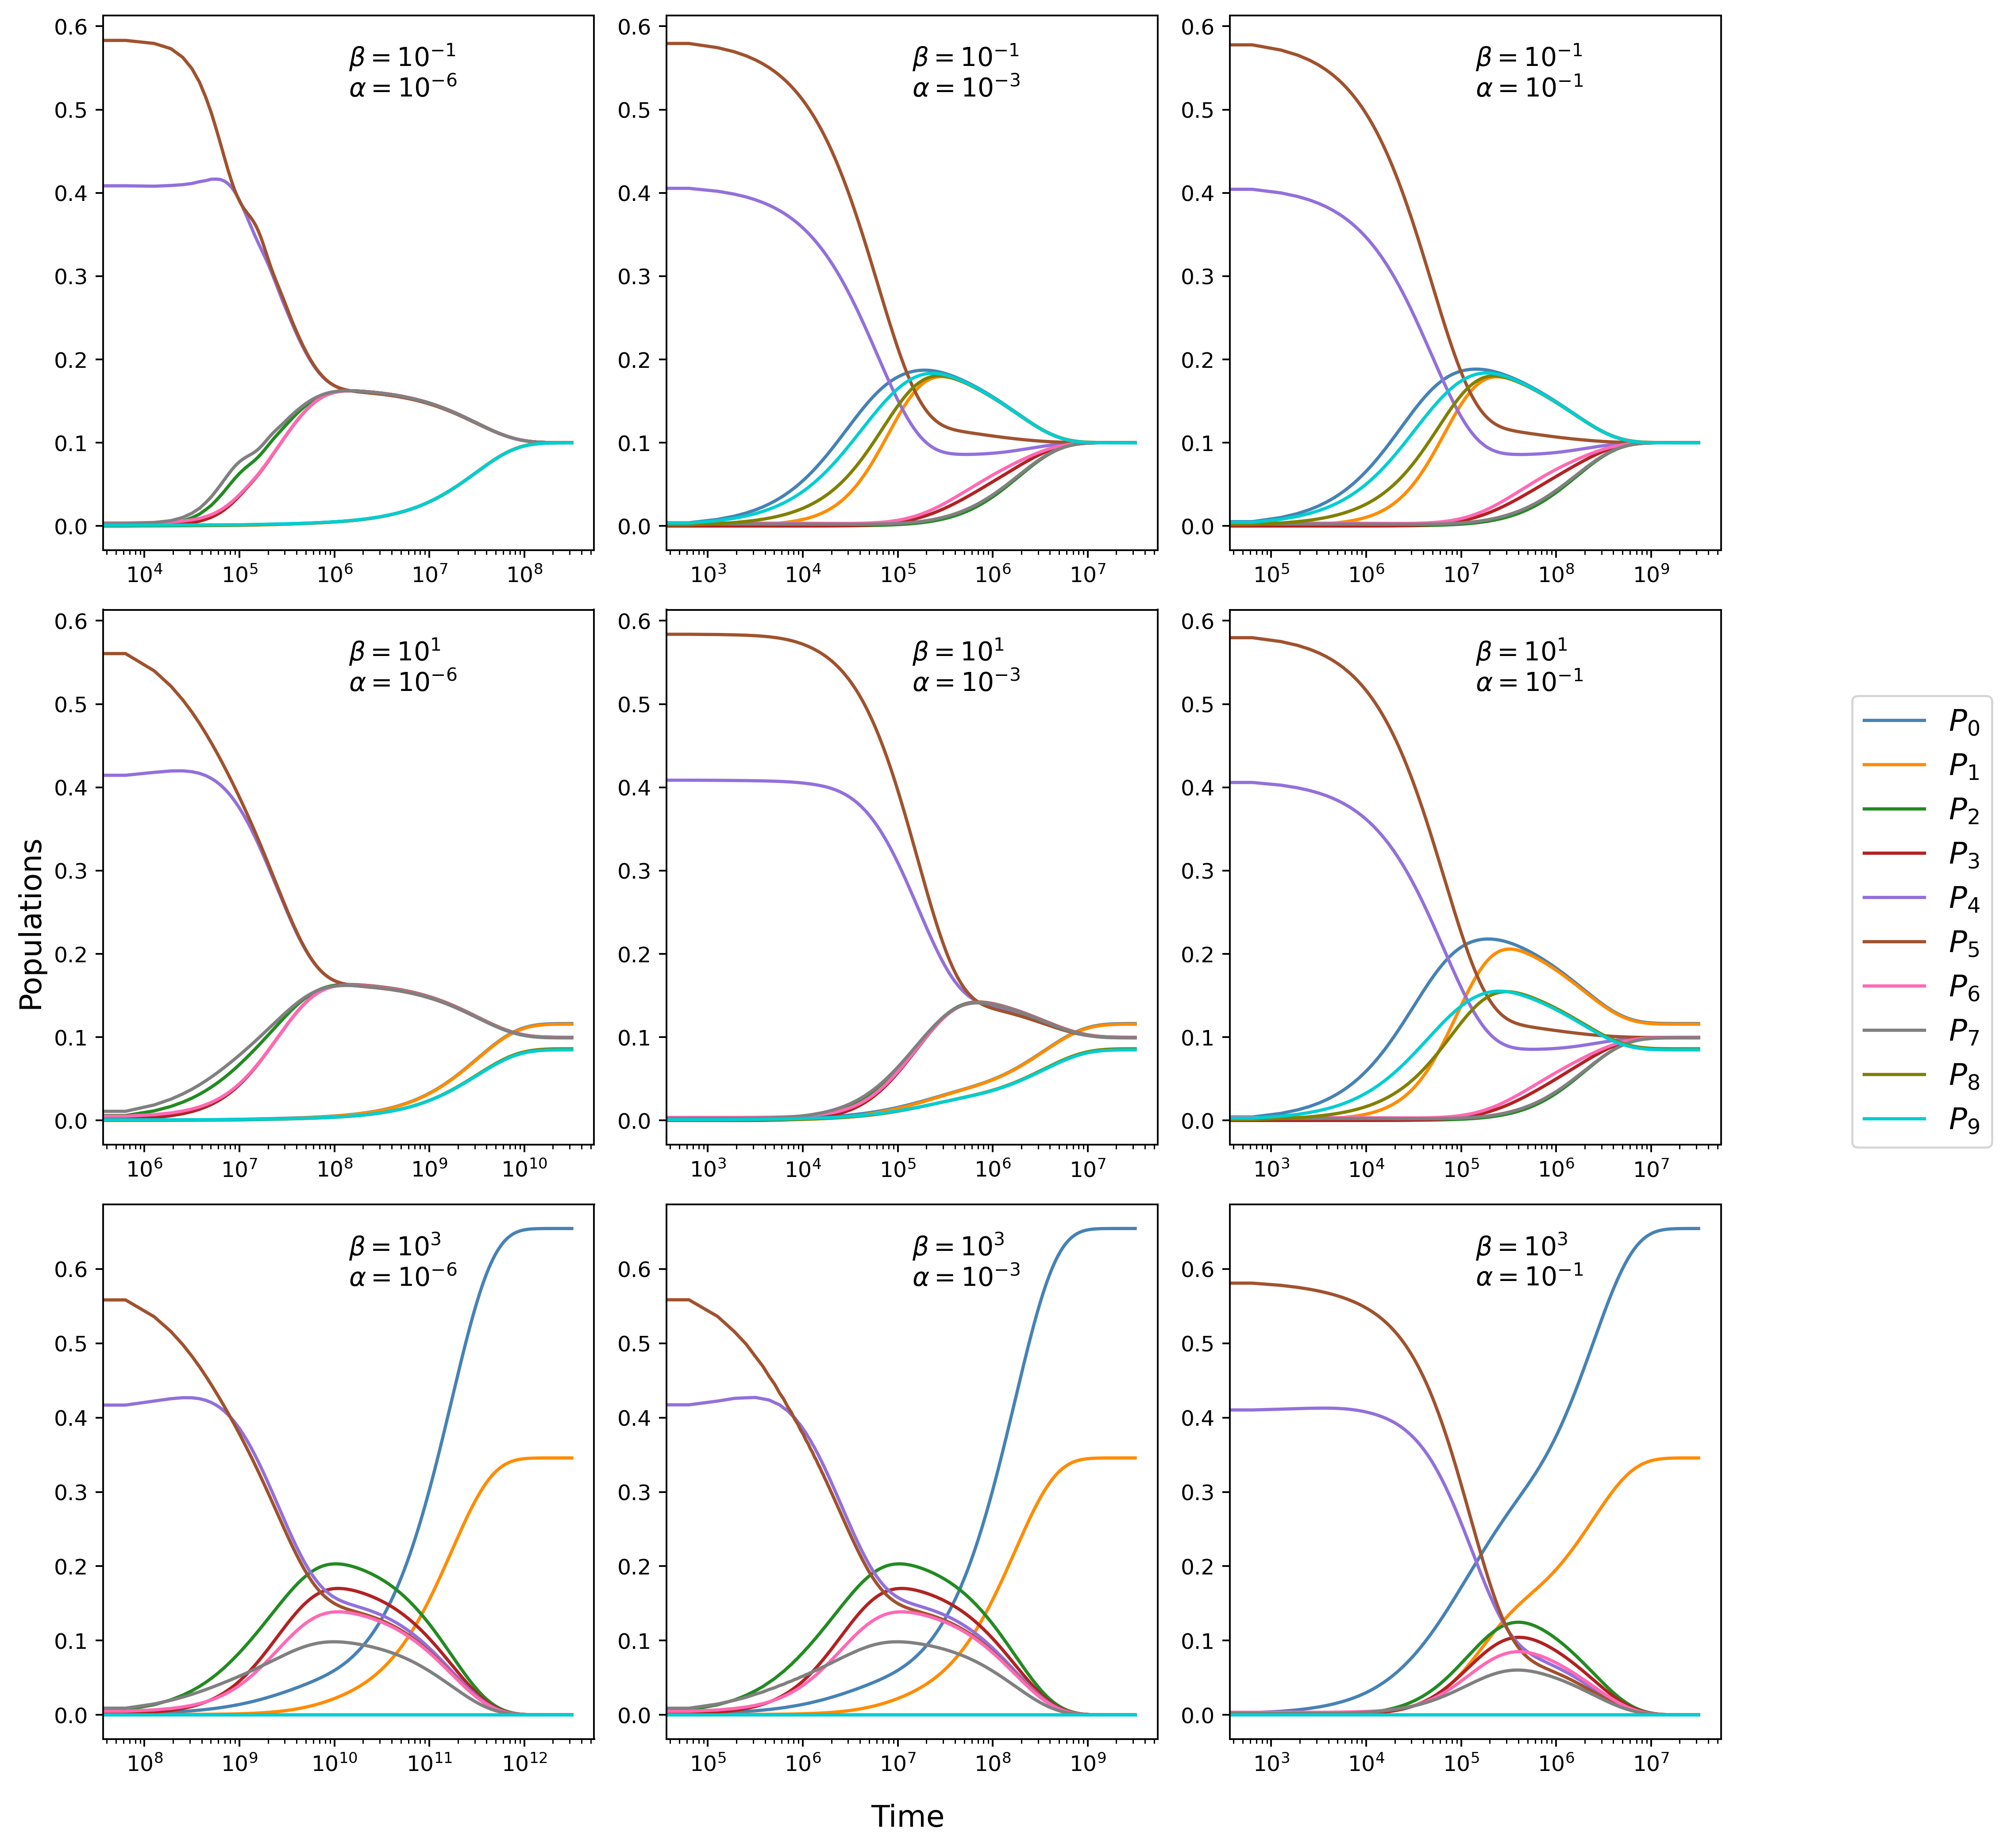

In [11]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

#coupling params
J_max = 1
power = 3 #power for coupling matrix/system hamiltonain - 3 for dipole-dipole like model

Betas=np.array([0.1,0.1,0.1,
                10,10,10,
                1000,1000,1000])
Alphas=np.array([10**(-6),10**(-3),0.1,
                 10**(-6),10**(-3),0.1,
                 10**(-6),10**(-3),0.1])
#bath params- assuming 3 decoupled ohmic baths
wc_list=np.array(50*np.ones(10))

#generate configuration B using Roi's code 
D = np.array([[ 26.42338043,  -7.94752626],
              [ 23.5676572 , -10.82584156],
              [ 12.9945502 , -15.04985626],
              [ 10.04355896, -17.75500788],
              [ 22.09827259,  11.50615309],
              [  4.77769072, -29.50708222],
              [  3.61769485,  13.64602815],
              [-13.15603736,  -3.06908283],
              [ -7.72037927,  25.74900317],
              [-22.17787943,  18.52470886]])

#config A coupling matrix 
'''D=np.array([[ 31.53553015,   3.44199744],
              [ 29.69692277,   2.38201959],
              [ 29.78424968,   6.90942031],
              [ 11.22998167,   8.6657443 ],
              [ 11.4583447 ,  -2.66983921],
              [ 13.21948377, -17.481802  ],
              [  0.64608129,  21.77132371],
              [  5.82726916, -30.27930513],
              [-15.20226319, -15.91983595],
              [-15.69793743,  24.45663107]])
'''
#system hamiltonian in local basis, degenerate case
N = D.shape[0]
H = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            dist = np.linalg.norm(D[i] - D[j])
            H[i, j] = J_max / dist**power
#system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)

def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0
#initial conditions
rho_init=np.zeros((10,10))
rho_init[5,5]=1   #initial density matrix in local basis - state |A><A|

#time arrays custom for each plot, 9 in total
endpts=[10**8.5,10**7.5,10**9.5,
        10**10.5,10**7.5,10**7.5,
        10**12.5,10**9.5,10**7.5]

def evolve_function(B,A,endpt):
    beta_list=np.array(B*np.ones(10))
    alpha_list=np.array(A*np.ones(10))
    def gamma_func(w): #Laplace transforms of bath correlation functions 
        gammas = []
        absw = abs(w)
        for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

            if absw < 1e-12:
                # Ohmic zero-frequency limit:
                # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
                g = (np.pi/2)*(alpha/beta)
            elif w > 0:
                g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
            else:
                g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
            gammas.append(g + 0j) #ensures dtype is complex with 0 complex part

        return np.array(gammas, dtype=np.complex128)

    R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-8,True) 

    time_steps=np.linspace(0,endpt,5*(10**4))

    #time eveolve
    rho_t=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=True)
    rho_t=np.array(rho_t)
    #populations in each site
    populations=[]
    for k in range(H.shape[0]):
        populations.append(rho_t[:,k,k].real)
    populations=np.array(populations)
    return populations,time_steps

colours=['steelblue','darkorange',
         'forestgreen','firebrick','mediumpurple','sienna',
         'hotpink','grey','olive','darkturquoise']

fig,axes=plt.subplots(3,3,figsize=(12,12))

for j,(B,A, endpt) in enumerate(zip(Betas,Alphas,endpts)): 
    a=j//3
    b=j%3
    populations,time_steps=evolve_function(B,A,endpt)
    for k in range(H.shape[0]):
        axes[a,b].plot(time_steps,populations[k,:],color=colours[k],label=f'$P_{k}$')

    axes[a,b].set_xscale('log')
    expB = int(np.log10(B))
    expA= int(np.log10(A))
    
    axes[a,b].text(0.5, 0.95, f'$\\beta=10^{{{expB}}}$\n$\\alpha=10^{{{expA}}}$', transform=axes[a,b].transAxes, 
            fontsize=12, verticalalignment='top')

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc='center left',bbox_to_anchor=(1, 0.5),fontsize=14)
fig.supxlabel('Time',fontsize=14)
fig.supylabel('Populations',fontsize=14)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()